In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [2]:
REL_TSV = Path("./data/en/train/eng-train-rel.tsv")
ENT_TSV = Path("./data/en/train/eng-train-ent.tsv")
TEXTS_DIR = Path("./data/en/train/texts")

In [3]:
entities = pd.read_csv(ENT_TSV, sep="\t", dtype=str)

entities.head()

,document_id,entity_type,entity_text,entity_span
0,25591652_en,DISO,non IGE,1586-1593
1,25591652_en,FINDING,seizure aggravation,202-221
2,25591652_en,FINDING,epileptic seizure aggravation,22-51
3,25591652_en,DISO,seizure,32-39
4,25591652_en,DISO,epileptic seizure,22-39


In [4]:
print(f'total entities: {len(entities)}, unique entities: {entities['entity_type'].nunique()}, total docs: {entities['document_id'].nunique()}')

total entities: 3861, unique entities: 8, total docs: 55


In [5]:
entities['entity_type'].value_counts()

entity_type
DISO                1171
ANATOMY              889
CHEM                 630
FINDING              480
PHYS                 402
LABPROC              220
INJURY_POISONING      40
DEVICE                29
Name: count, dtype: int64

In [6]:
entities['entity_text'].value_counts().head()

entity_text
pain        24
brain       24
ischemia    17
cerebral    16
EEG         15
Name: count, dtype: int64

In [7]:
entities.groupby(
    ["entity_type", "entity_text"]
    ).size().reset_index(name="count").sort_values(["entity_type", "count"], ascending=[True, False]).groupby("entity_type").head(5)

,entity_type,entity_text,count
78,ANATOMY,brain,24
106,ANATOMY,cerebral,16
68,ANATOMY,blood,14
59,ANATOMY,artery,13
103,ANATOMY,cell,13
411,CHEM,ARTRA,12
545,CHEM,cytoflavin,12
674,CHEM,sertindole,11
450,CHEM,MSM,10
412,CHEM,ARTRA MSM,9


In [8]:
entities[['document_id']].value_counts().head()

document_id
26528618_en    132
25823269_en    130
26591552_en    126
25842923_en    125
26978046_en    118
Name: count, dtype: int64

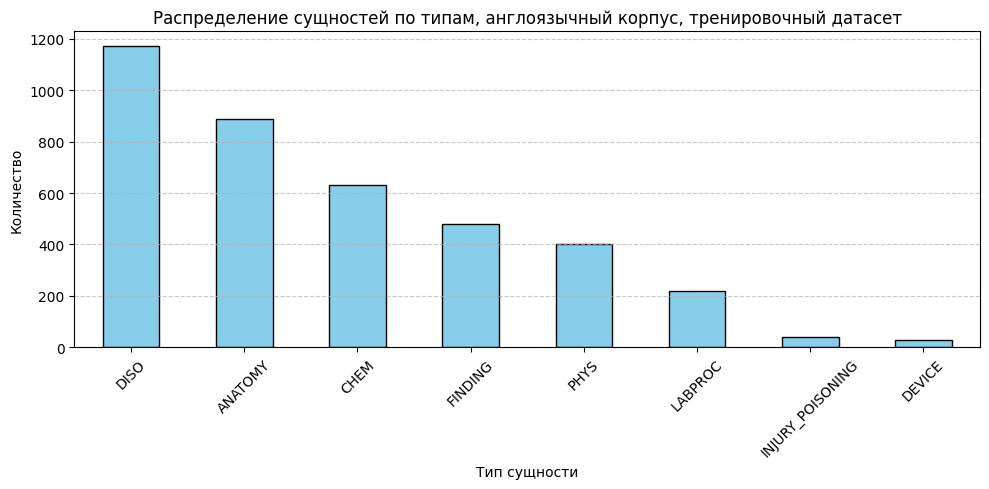

In [9]:
plt.figure(figsize=(10, 5))
entities['entity_type'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение сущностей по типам, англоязычный корпус, тренировочный датасет')
plt.xlabel('Тип сущности')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
relations = pd.read_csv(REL_TSV, sep="\t")

relations.head()

,document_id,relation,head_text,head_span,head_type,tail_text,tail_span,tail_type
0,25591652_en,ABBREVIATION,idiopathic generalized epilepsies,510-543,DISO,IGE,545-548,DISO
1,25591652_en,ALTERNATIVE_NAME,topiramate,352-362,CHEM,TPM,364-367,CHEM
2,25591652_en,ALTERNATIVE_NAME,valproates,389-399,CHEM,VPA,401-404,CHEM
3,25591652_en,ALTERNATIVE_NAME,carbamazepine,413-426,CHEM,CBZ,428-431,CHEM
4,25591652_en,ALTERNATIVE_NAME,lamotrigine,440-451,CHEM,LTG,453-456,CHEM


In [11]:
print(f'total relations: {len(relations)}, unique relations (exclude no_relation): {relations['relation'].nunique()}')

total relations: 3193, unique relations (exclude no_relation): 14


In [12]:
relations['relation'].value_counts()

relation
SUBCLASS_OF           743
HAS_CAUSE             579
AFFECTS               362
ASSOCIATED_WITH       325
PART_OF               204
TO_DETECT_OR_STUDY    164
PHYSIOLOGY_OF         150
FINDING_OF            121
ORIGINS_FROM          120
TREATED_USING         101
ABBREVIATION           97
ALTERNATIVE_NAME       95
USED_IN                89
APPLIED_TO             43
Name: count, dtype: int64

In [13]:
(
    relations.groupby(['relation', 'head_type', 'tail_type'])
        .size()
        .reset_index(name='count')
        .sort_values(by=['relation', 'count'], ascending=[True, False])
        .head(3)
)

,relation,head_type,tail_type,count
3,ABBREVIATION,DISO,DISO,46
6,ABBREVIATION,PHYS,PHYS,17
1,ABBREVIATION,CHEM,CHEM,16


In [14]:
(   
    relations.groupby(['relation', 'head_text', 'tail_text']).size()
        .reset_index(name='count')
        .sort_values(by=['relation', 'count'], ascending=[True, False])
        .groupby('relation')
        .head(3)
)

,relation,head_text,tail_text,count
27,ABBREVIATION,chronic brain ischemia,CBI,2
40,ABBREVIATION,coronary heart disease,CHD,2
79,ABBREVIATION,pulmonary arterial hypertension,PAH,2
176,AFFECTS,chronic brain ischemia,brain,8
146,AFFECTS,blunt neck trauma,neck,4
154,AFFECTS,brain ischemia,brain,4
422,ALTERNATIVE_NAME,arterial hypertension,hypertension,4
403,ALTERNATIVE_NAME,C2 vertebra,C2,3
411,ALTERNATIVE_NAME,SCT angiography,SCT,2
485,APPLIED_TO,BSS,anterior chamber,1


In [15]:
all_entities_in_rels = pd.concat([
        relations[['head_text', 'head_type']].rename(columns={'head_text':'text', 'head_type':'type'}),
        relations[['tail_text', 'tail_type']].rename(columns={'tail_text':'text', 'tail_type':'type'})
    ])

all_entities_in_rels.value_counts(['text', 'type']).head(10).reset_index(name='degree')

,text,type,degree
0,expression,PHYS,43
1,sertindole,CHEM,37
2,ARTRA MSM,CHEM,31
3,EEG,LABPROC,28
4,brain ischemia,DISO,28
5,brain,ANATOMY,28
6,atopic dermatitis,DISO,24
7,pain,DISO,23
8,cells,ANATOMY,23
9,chronic brain ischemia,DISO,21


In [16]:
relations['document_id'].value_counts()

document_id
26528618_en    147
25842923_en    129
26485778_en    122
26978176_en    116
27030096_en    104
26977789_en    102
26978046_en     96
25842921_en     92
26226776_en     90
26978491_en     88
26591552_en     87
25591652_en     85
27022660_en     84
25823269_en     81
25872388_en     79
25909792_en     75
26978418_en     75
26977723_en     74
26036068_en     73
26978232_en     72
26978233_en     69
26081319_en     65
26978172_en     64
26356060_en     56
26977916_en     56
26245096_en     55
26821419_en     49
26953424_en     49
26978639_en     49
26978498_en     48
26977764_en     46
25726786_en     43
26146046_en     43
26978504_en     43
26390722_en     42
25823275_en     41
26356162_en     40
26821417_en     40
26355937_en     36
26978499_en     36
26356616_en     35
26310014_en     34
26356615_en     32
26977908_en     30
27029445_en     27
27030332_en     27
26356515_en     26
26271558_en     25
25823273_en     24
26271422_en     22
26525622_en     19
26525625_en     18


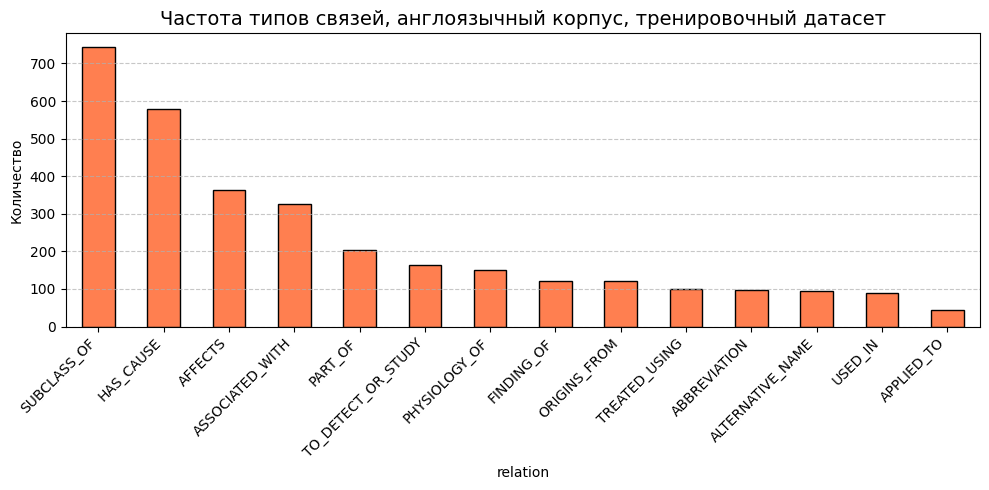

In [17]:
plt.figure(figsize=(10, 5))
relations['relation'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Частота типов связей, англоязычный корпус, тренировочный датасет', fontsize=14)
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

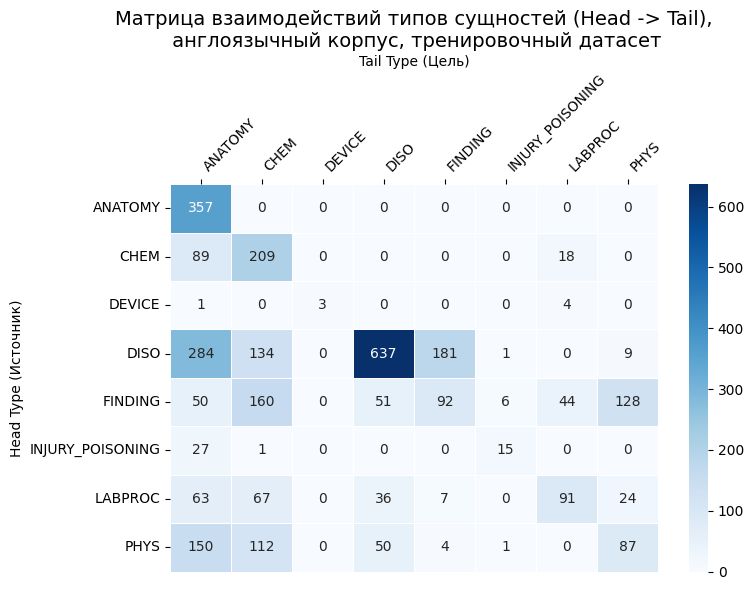

In [28]:
all_entities = sorted(entities['entity_type'].unique()) 

plt.figure(figsize=(8, 6))

cross_tab = pd.crosstab(relations['head_type'], relations['tail_type'])
cross_tab = cross_tab.reindex(index=all_entities, columns=all_entities, fill_value=0)

ax = sns.heatmap(cross_tab, 
                     annot=True, 
                     fmt='d', 
                     cmap='Blues', 
                     linewidths=.5,
                     cbar=True)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title('Матрица взаимодействий типов сущностей (Head -> Tail),\n англоязычный корпус, тренировочный датасет', fontsize=14)
plt.xlabel('Tail Type (Цель)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='left')
plt.ylabel('Head Type (Источник)')
plt.tight_layout()
plt.show()

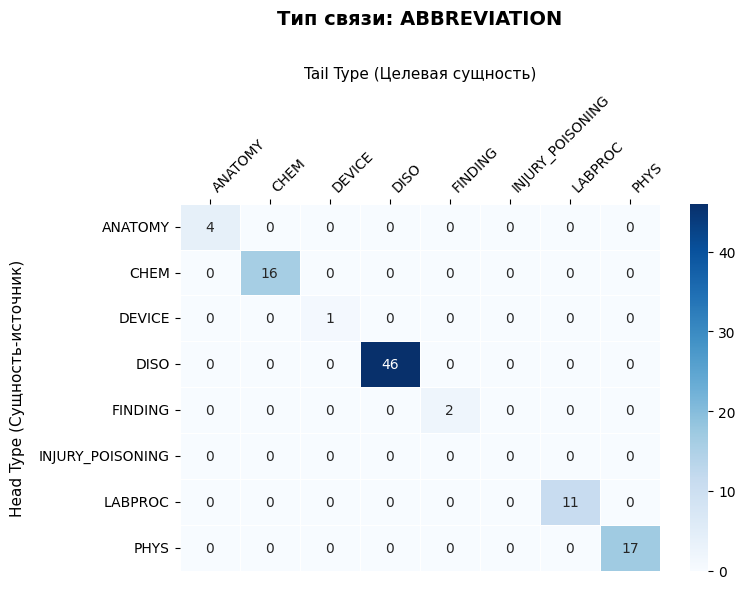

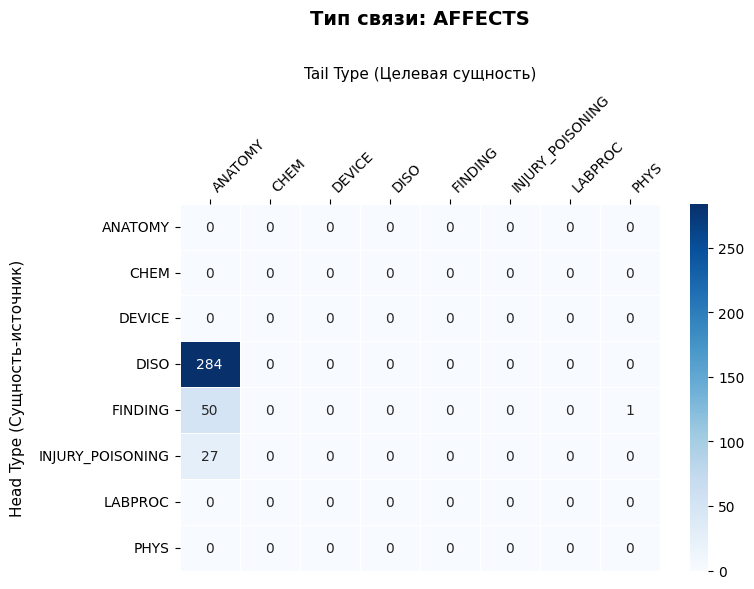

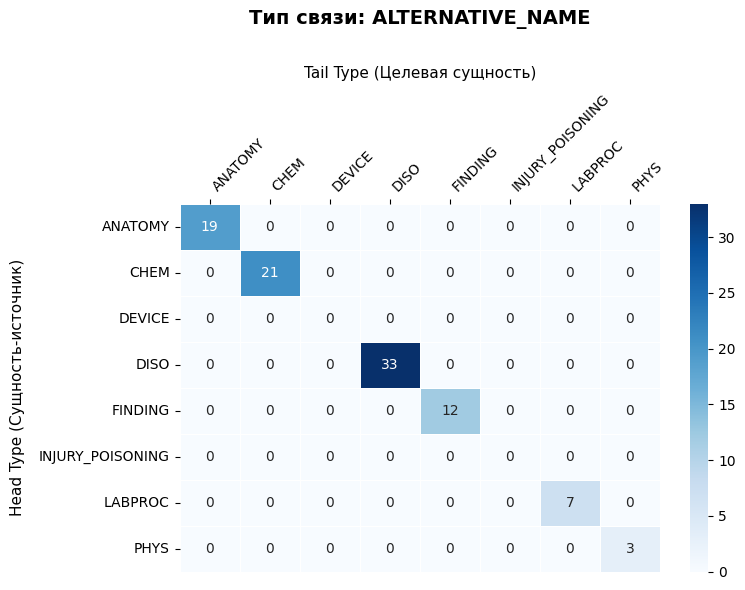

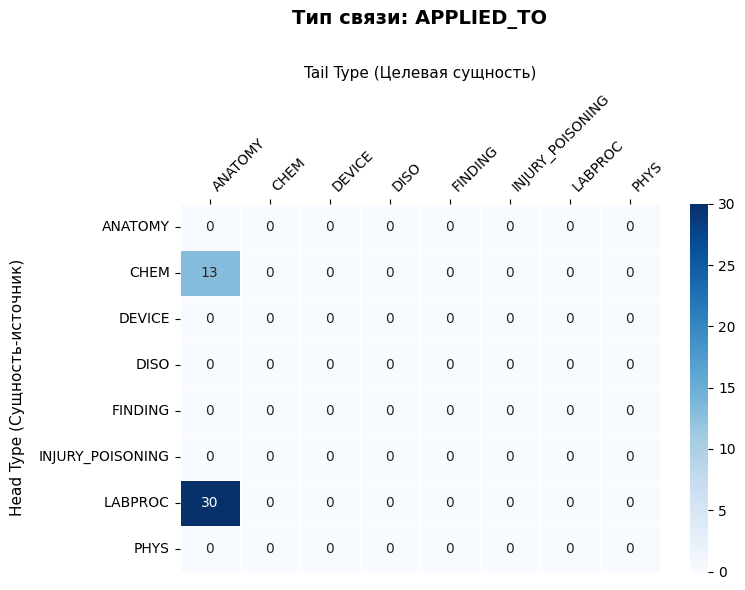

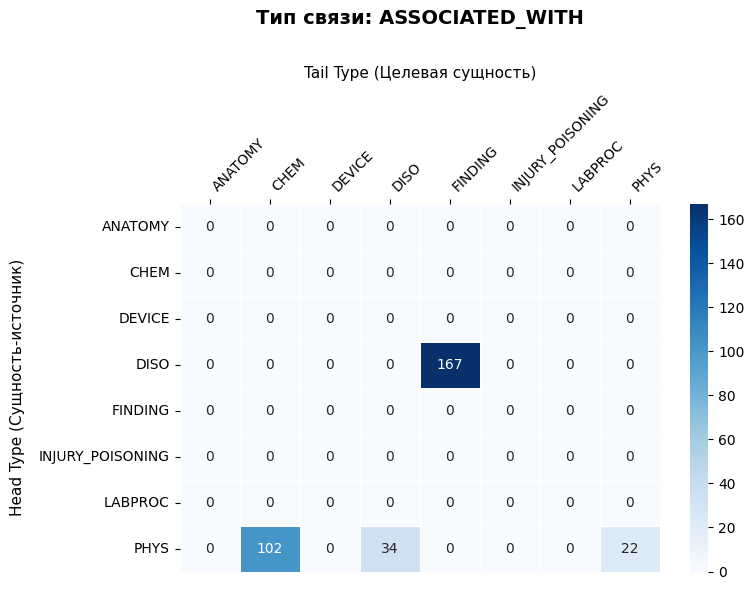

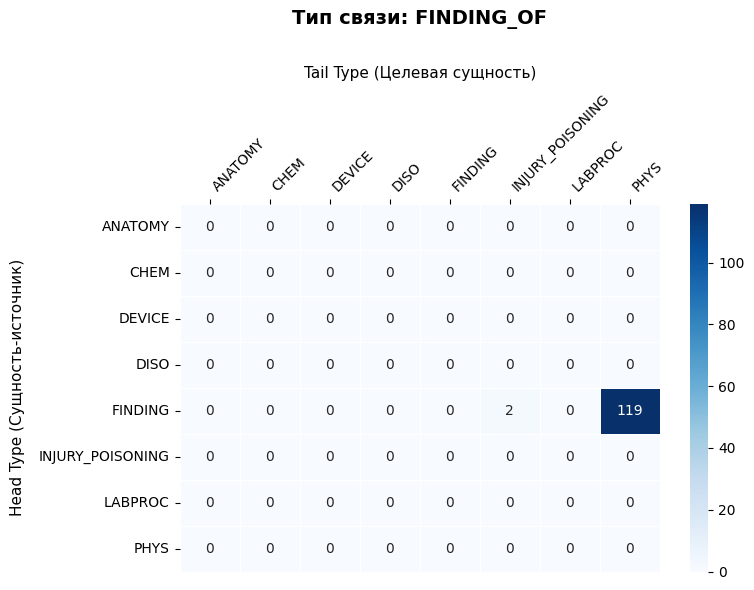

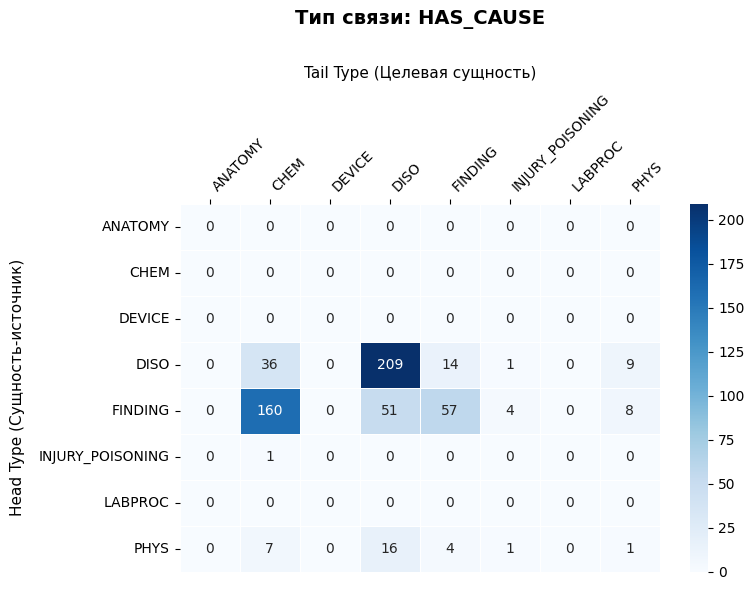

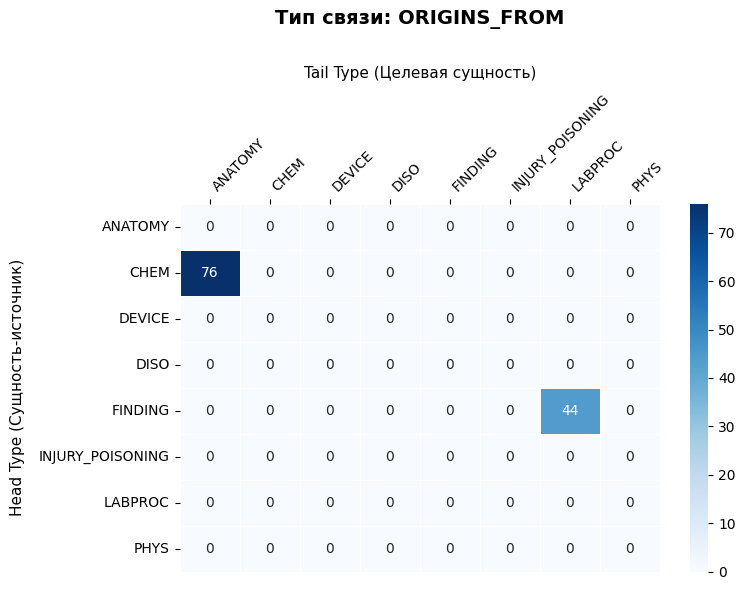

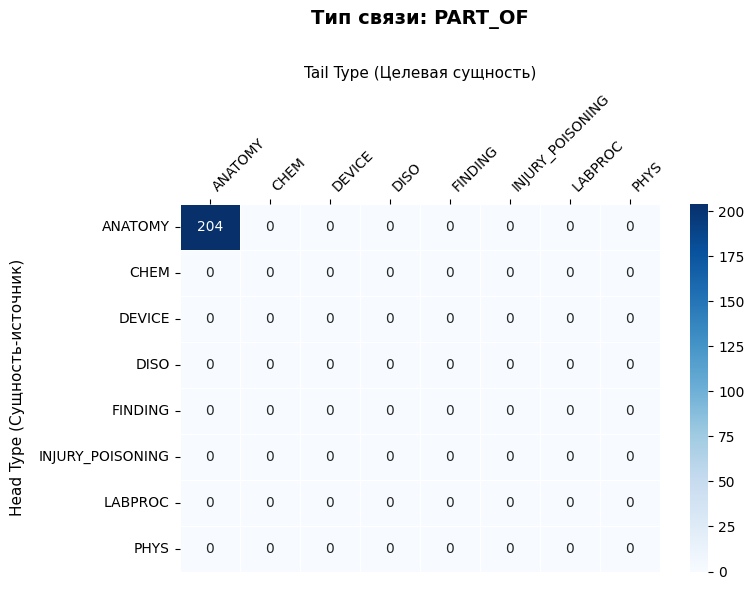

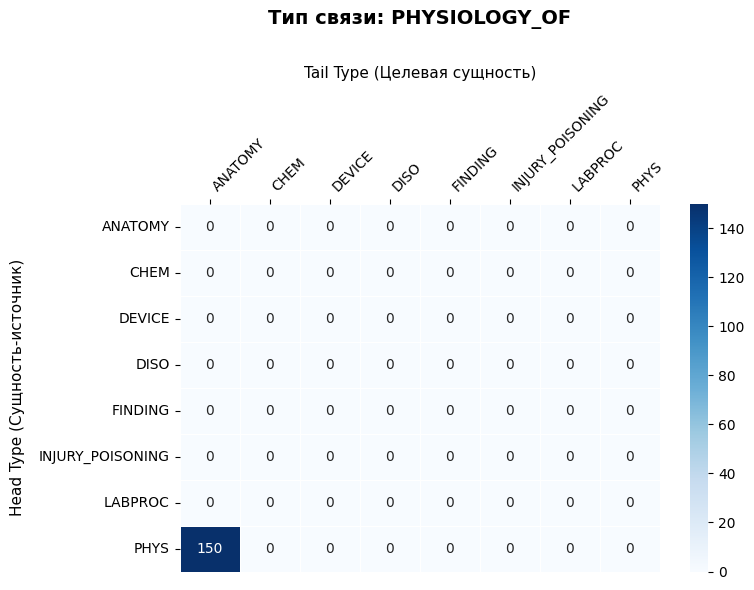

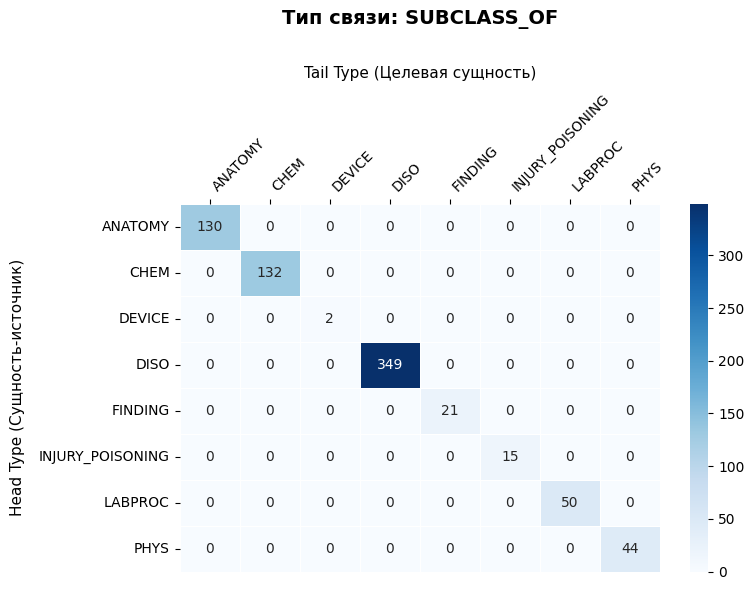

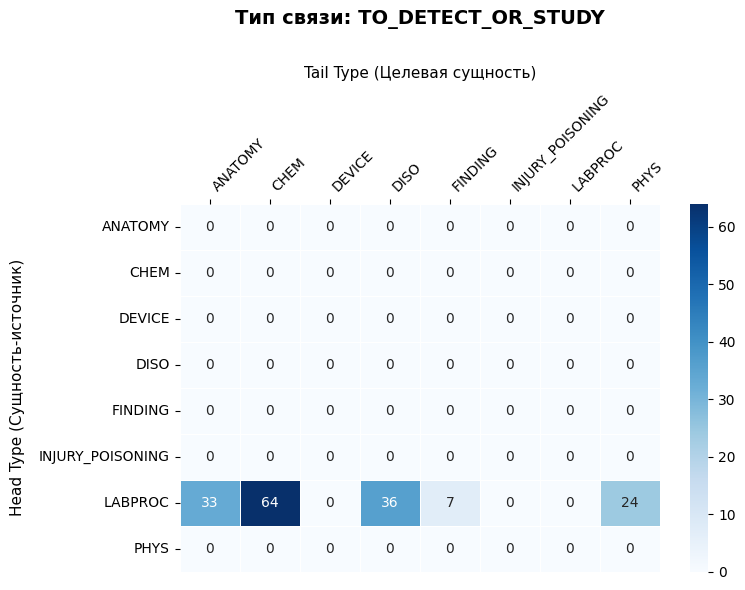

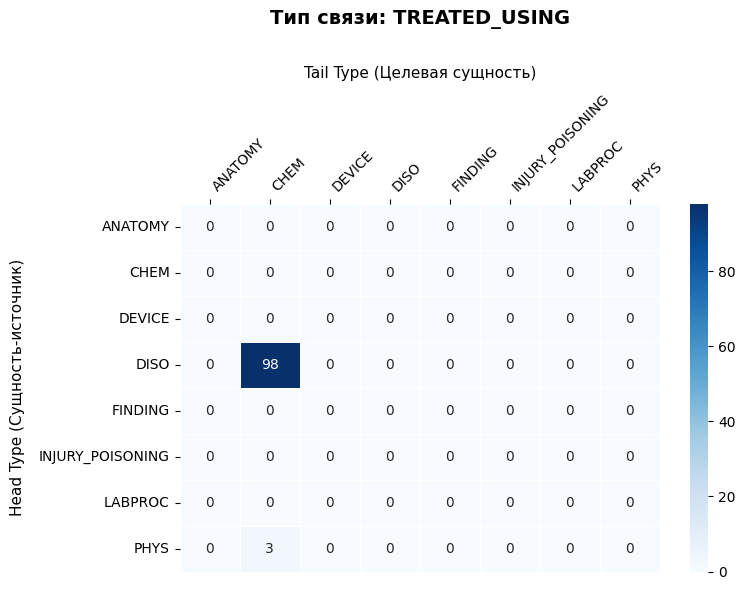

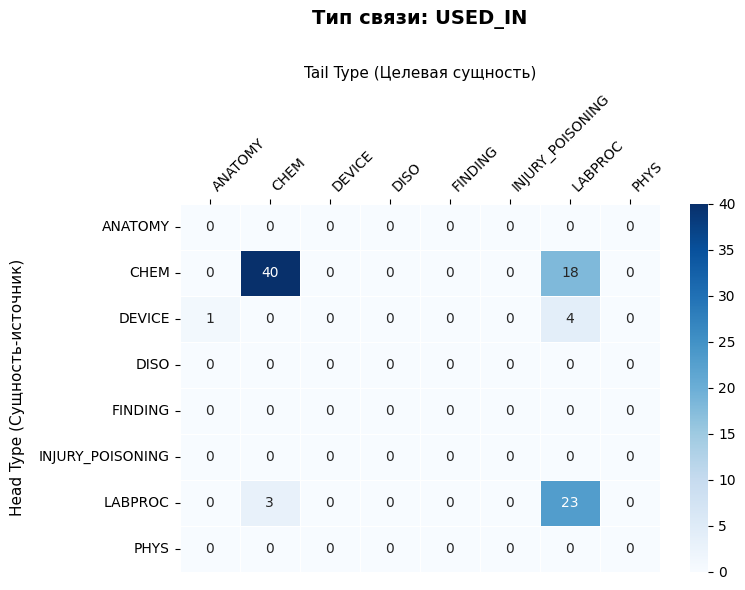

In [19]:
unique_relations = sorted(relations['relation'].unique())
all_entities = sorted(entities['entity_type'].unique()) 

for rel in unique_relations:
        df_subset = relations[relations['relation'] == rel]
        
        cross_tab = pd.crosstab(df_subset['head_type'], df_subset['tail_type'])
        cross_tab = cross_tab.reindex(index=all_entities, columns=all_entities, fill_value=0)

        plt.figure(figsize=(8, 6)) 
        ax = sns.heatmap(cross_tab, 
                         annot=True, 
                         fmt='d', 
                         cmap='Blues', 
                         linewidths=.5,
                         cbar=True)
        
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        
        plt.xlabel('Tail Type (Целевая сущность)', fontsize=11, labelpad=10)
        plt.ylabel('Head Type (Сущность-источник)', fontsize=11, labelpad=10)
        plt.title(f'Тип связи: {rel}', fontsize=14, fontweight='bold', pad=30)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='left')
        plt.setp(ax.get_yticklabels(), rotation=0)
        plt.tight_layout()
        plt.show()

In [20]:
def load_texts(texts_dir):
    """Load all .txt files from directory into {doc_id: text} dict."""
    texts = {}
    for txt_file in Path(texts_dir).glob("*.txt"):
        texts[txt_file.stem] = txt_file.read_text(encoding="utf-8")
    return texts


def load_entities(entity_tsv):
    """Read entity TSV -> {doc_id: [(type, text, span), ...]}."""
    df = pd.read_csv(entity_tsv, sep="\t")
    entities_by_doc = {}
    for _, row in df.iterrows():
        doc_id = str(row["document_id"])
        entry = (row["entity_type"], str(row["entity_text"]), str(row["entity_span"]))
        entities_by_doc.setdefault(doc_id, []).append(entry)
    return entities_by_doc


def parse_span(span_str):
    """Parse 'start-end' to (start, end)."""
    start, end = span_str.split("-")
    return int(start), int(end)


def generate_pairs(entities, valid_type_pairs=None):
    """Generate ordered entity pairs, optionally filtered by valid type combinations."""
    pairs = []
    for i, e1 in enumerate(entities):
        for j, e2 in enumerate(entities):
            if i == j:
                continue
            if valid_type_pairs is not None and (e1[0], e2[0]) not in valid_type_pairs:
                continue
            pairs.append((e1, e2))
    return pairs


def find_sentence_segment(text, head_start, head_end, tail_start, tail_end, lang="english"):
    """Find minimal sentence segment containing both entities. Returns (segment_text, offset)."""
    try:
        sent_tokenizer = nltk.data.load(f"tokenizers/punkt_tab/{lang}.pickle")
    except LookupError:
        sent_tokenizer = nltk.data.load("tokenizers/punkt_tab/english.pickle")
    sentences = list(sent_tokenizer.span_tokenize(text))
    if not sentences:
        return text, 0
    entity_min = min(head_start, tail_start)
    entity_max = max(head_end, tail_end)
    first_idx = 0
    last_idx = len(sentences) - 1
    for i, (s_start, s_end) in enumerate(sentences):
        if s_start <= entity_min < s_end:
            first_idx = i
        if s_start < entity_max <= s_end:
            last_idx = i
    if first_idx > last_idx:
        first_idx, last_idx = last_idx, first_idx
    first_idx = max(0, first_idx - 1)
    last_idx = min(len(sentences) - 1, last_idx + 1)
    seg_start = sentences[first_idx][0]
    seg_end = sentences[last_idx][1]
    return text[seg_start:seg_end], seg_start

In [21]:
texts = load_texts(TEXTS_DIR)
entities_by_doc = load_entities(ENT_TSV)

print(f"docs count: {len(texts)}")
print(f"docs with entities: {len(entities_by_doc)}")

docs count: 55
docs with entities: 55


In [22]:
def create_valid_type_pairs(df_relations, min_freq=10):
    if df_relations.empty:
        return set()

    pair_counts = df_relations.groupby(['head_type', 'tail_type']).size()
    valid_pairs_series = pair_counts[pair_counts >= min_freq]
    valid_type_pairs = set(valid_pairs_series.index.tolist())
    
    print(f"Сгенерирован White List: {len(valid_type_pairs)} разрешенных комбинаций (порог: {min_freq}).")
    return valid_type_pairs

valid_type_pairs = create_valid_type_pairs(relations)

Сгенерирован White List: 25 разрешенных комбинаций (порог: 10).


In [23]:
pipeline_stats = []
    
total_raw_pairs = 0
total_filtered_pairs = 0

for doc_id, text in texts.items():
    doc_entities = entities_by_doc.get(doc_id, [])
    if not doc_entities:
        continue
        
    raw_pairs = generate_pairs(doc_entities, valid_type_pairs=None)
    total_raw_pairs += len(raw_pairs)

    actual_pairs = generate_pairs(doc_entities, valid_type_pairs=valid_type_pairs)
    total_filtered_pairs += len(actual_pairs)
    
    for head_ent, tail_ent in actual_pairs:
        h_type, h_text, h_span = head_ent
        t_type, t_text, t_span = tail_ent
        
        h_start, h_end = parse_span(h_span)
        t_start, t_end = parse_span(t_span)
        
        entity_distance = t_start - h_end if t_start > h_start else h_start - t_end
        
        segment, offset = find_sentence_segment(text, h_start, h_end, t_start, t_end)
        
        segment_chars = len(segment)
        segment_words = len(segment.split())
        
        pipeline_stats.append({
            "doc_id": doc_id,
            "head_type": h_type,
            "tail_type": t_type,
            "pair_types": f"{h_type} -> {t_type}",
            "distance_chars": abs(entity_distance),
            "segment_chars": segment_chars,
            "segment_words": segment_words
        })

In [24]:
df_stats = pd.DataFrame(pipeline_stats)

print(f"pair count: {total_raw_pairs:,}")
print(f"pair per doc: {total_filtered_pairs / len(texts):.1f}")

print(f"mean segment len: {df_stats['segment_words'].mean():.0f} words / {df_stats['segment_chars'].mean():.0f} char")
print(f"max segment len: {df_stats['segment_words'].max():.0f} words")

pair count: 317,976
pair per doc: 3932.5
mean segment len: 166 words / 1125 char
max segment len: 433 words


In [25]:
df_stats['segment_words'].quantile(0.5)

np.float64(155.0)

In [26]:
len(actual_pairs)

807

In [27]:
bert_overflow = (df_stats['segment_words'] > 400).sum()
bert_overflow

np.int64(1114)